# PCA Dimension Reduction

**Project question:** Can a few orthogonal directions summarize the main variation in several correlated customer features?

By the end of this notebook, you should be able to:

- fit PCA to standardized numeric features
- interpret explained variance, scores, and loadings
- avoid treating component signs or latent patterns as causal factors

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv(DATA / 'simulated_customer_profiles.csv')
features = ['visits_per_month', 'avg_order_value', 'discount_rate', 'email_opens', 'tenure_months', 'support_contacts', 'returns_per_year']
X_scaled = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=len(features))
scores = pca.fit_transform(X_scaled)
explained = pd.DataFrame({
    'component': [f'PC{i}' for i in range(1, len(features) + 1)],
    'explained_variance_ratio': pca.explained_variance_ratio_,
})
explained['cumulative_explained_variance'] = explained['explained_variance_ratio'].cumsum()
explained

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.638468,0.638468
1,PC2,0.159401,0.797869
2,PC3,0.077412,0.875281
3,PC4,0.055067,0.930347
4,PC5,0.030412,0.960760
5,PC6,0.021650,0.982410
6,PC7,0.017590,1.000000


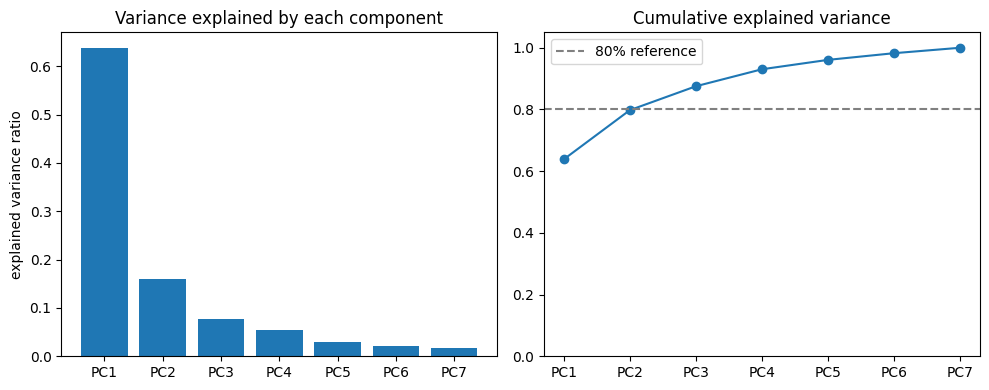

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(explained['component'], explained['explained_variance_ratio'])
axes[0].set_ylabel('explained variance ratio')
axes[0].set_title('Variance explained by each component')
axes[1].plot(explained['component'], explained['cumulative_explained_variance'], marker='o')
axes[1].axhline(0.80, color='gray', linestyle='--', label='80% reference')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
plt.tight_layout()

Explained variance measures representation of predictor variation, not predictive value for a response. An 80% line is a descriptive reference, not a universal component-selection rule.

Text(0.5, 1.0, 'PCA scores colored by synthetic latent segment')

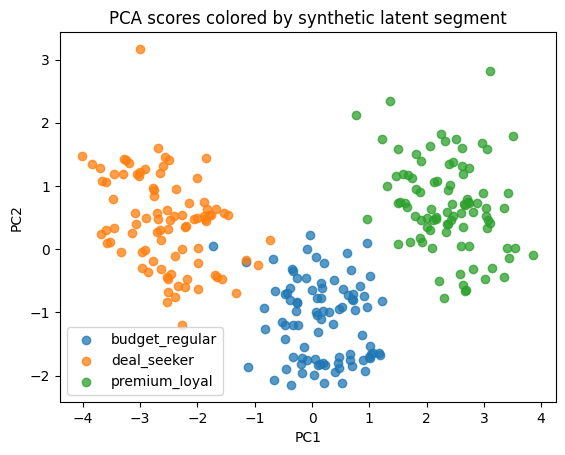

In [6]:
score_df = pd.DataFrame(scores[:, :2], columns=['PC1', 'PC2'])
score_df['true_segment'] = df['true_segment']
for segment, part in score_df.groupby('true_segment'):
    plt.scatter(part['PC1'], part['PC2'], label=segment, alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA scores colored by synthetic latent segment')

`true_segment` was excluded from PCA and is used only to color the teaching plot. Real unsupervised projects usually do not have a known latent label for this comparison.

In [7]:
loadings = pd.DataFrame(
    pca.components_[:3].T, index=features, columns=['PC1', 'PC2', 'PC3']
)
loadings

,PC1,PC2,PC3
visits_per_month,0.446431,0.027410,0.130407
avg_order_value,0.311432,0.578744,0.251573
discount_rate,-0.395730,0.284705,-0.132212
email_opens,0.434236,0.130116,0.111428
tenure_months,0.436694,0.082052,0.079738
support_contacts,-0.344334,0.017801,0.918583
returns_per_year,-0.221988,0.747842,-0.199136


**Interpretation:** Large absolute loadings identify variables contributing strongly to a component. The sign of an entire PCA component can flip without changing the solution, so interpret relative direction and magnitude rather than attaching meaning to an arbitrary sign. PCA reveals covariance structure, not causality.